# Atividade Prática: Explorando Dados na Web com Python


In [2]:
import io

import pandas as pd
import requests
from bs4 import BeautifulSoup

HEADERS = {'User-Agent': 'AtividadeDadosWebPython/1.0 (projeto universitario)'}
TIMEOUT = 10

## Nível 1: Básico (URLs, Parâmetros e Cabeçalhos)

### 1.1 Requisição GET para o JSONPlaceholder


In [3]:
url_posts = 'https://jsonplaceholder.typicode.com/posts'

resposta = requests.get(url_posts, timeout=TIMEOUT)
posts = resposta.json()

print(f'Total de posts retornados: {len(posts)}')
posts[0]

Total de posts retornados: 100


{'userId': 1,
 'id': 1,
 'title': 'sunt aut facere repellat provident occaecati excepturi optio reprehenderit',
 'body': 'quia et suscipit\nsuscipit recusandae consequuntur expedita et cum\nreprehenderit molestiae ut ut quas totam\nnostrum rerum est autem sunt rem eveniet architecto'}

### 1.2, 1.3 e 1.4 Parâmetros, cabeçalhos e status

- **1.2:** `params` filtra os posts do `userId` igual a 2 e limita a 5 resultados.
- **1.3:** `headers` envia um `User-Agent` personalizado com o nome do projeto.
- **1.4:** imprime o `status_code` e a URL final montada pelo `requests` (sempre com `timeout`).


In [4]:
parametros = {'userId': 2, '_limit': 5}

resposta = requests.get(url_posts, params=parametros, headers=HEADERS, timeout=TIMEOUT)

print(f'Status HTTP: {resposta.status_code}')
print(f'URL final: {resposta.url}')
print(f'User-Agent enviado: {resposta.request.headers["User-Agent"]}')

pd.DataFrame(resposta.json())[['userId', 'id', 'title']]

Status HTTP: 200
URL final: https://jsonplaceholder.typicode.com/posts?userId=2&_limit=5
User-Agent enviado: AtividadeDadosWebPython/1.0 (projeto universitario)


,userId,id,title
0,2,11,et ea vero quia laudantium autem
1,2,12,in quibusdam tempore odit est dolorem
2,2,13,dolorum ut in voluptas mollitia et saepe quo a...
3,2,14,voluptatem eligendi optio
4,2,15,eveniet quod temporibus


## Nível 2: Intermediário (JSON, Erros e Arquivos Binários)

### 2.1 Consultando CEPs no ViaCEP


In [5]:
ceps = ['01001000', '20040002', '30130010']
enderecos = []

for cep in ceps:
    resposta = requests.get(f'https://viacep.com.br/ws/{cep}/json/', headers=HEADERS, timeout=TIMEOUT)
    enderecos.append(resposta.json())

df_ceps = pd.DataFrame(enderecos)
df_ceps[['cep', 'logradouro', 'bairro', 'localidade', 'uf']]

,cep,logradouro,bairro,localidade,uf
0,01001-000,Praça da Sé,Sé,São Paulo,SP
1,20040-002,Avenida Rio Branco,Centro,Rio de Janeiro,RJ
2,30130-010,Praça Sete de Setembro,Centro,Belo Horizonte,MG


### 2.2 Função de download segura com `try/except`


In [ ]:
def download_seguro(url, **kwargs):
    try:
        resposta = requests.get(url, headers=HEADERS, timeout=TIMEOUT, **kwargs)
        resposta.raise_for_status()
        return resposta
    except requests.exceptions.HTTPError as erro:
        print(f'Não foi possível acessar {url}: o servidor respondeu com erro ({erro.response.status_code}).')
    except requests.exceptions.Timeout:
        print(f'O servidor demorou demais para responder: {url}')
    except requests.exceptions.RequestException as erro:
        print(f'Falha de conexão ao acessar {url}: {erro}')
    return None

download_seguro('https://httpbin.org/status/404')
download_seguro('https://httpbin.org/status/500')

resposta = download_seguro('https://jsonplaceholder.typicode.com/posts/1')
print(f'Sucesso: {resposta.status_code}' if resposta else 'Falhou')

Não foi possível acessar https://httpbin.org/status/404: o servidor respondeu com erro (404).
Não foi possível acessar https://httpbin.org/status/500: o servidor respondeu com erro (500).
Sucesso: 200


### 2.3 Baixando uma imagem aleatória do Picsum


Imagem salva (10370 bytes)


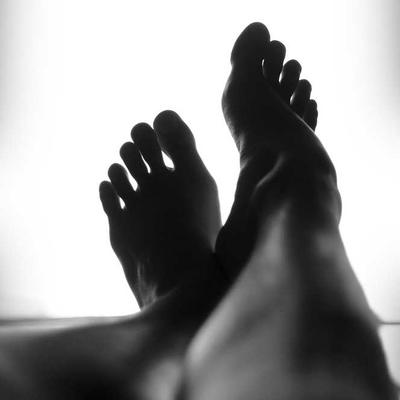

In [ ]:
from IPython.display import Image

resposta = download_seguro('https://picsum.photos/400/400')

if resposta:
    with open('imagem_aleatoria.jpg', 'wb') as arquivo:
        arquivo.write(resposta.content)
    print(f'Imagem salva ({len(resposta.content)} bytes)')

Image('imagem_aleatoria.jpg')

## Nível 3: Avançado (Webscraping e Ética)

### 3.1 Verificando o `robots.txt` antes da raspagem


In [8]:
from urllib.robotparser import RobotFileParser

url_base = 'https://books.toscrape.com/'

resposta = requests.get(url_base + 'robots.txt', headers=HEADERS, timeout=TIMEOUT)
print(f'Status do robots.txt: {resposta.status_code}')

if resposta.status_code == 200:
    print(resposta.text)
else:
    print('O site não possui robots.txt (404), então não há restrições declaradas para a raspagem.')

robots = RobotFileParser()
robots.set_url(url_base + 'robots.txt')
robots.read()
print(f'Permitido raspar a página inicial? {robots.can_fetch(HEADERS["User-Agent"], url_base)}')

Status do robots.txt: 404
O site não possui robots.txt (404), então não há restrições declaradas para a raspagem.
Permitido raspar a página inicial? True


### 3.2 Extraindo título e preço dos 5 primeiros livros com BeautifulSoup


In [9]:
resposta = download_seguro(url_base)
resposta.encoding = 'utf-8'

soup = BeautifulSoup(resposta.text, 'html.parser')
livros = []

for produto in soup.select('article.product_pod')[:5]:
    titulo = produto.find('h3').find('a')['title']
    preco = produto.find('p', class_='price_color').text
    livros.append({'titulo': titulo, 'preco': preco})

df_livros = pd.DataFrame(livros)
df_livros

,titulo,preco
0,A Light in the Attic,£51.77
1,Tipping the Velvet,£53.74
2,Soumission,£50.10
3,Sharp Objects,£47.82
4,Sapiens: A Brief History of Humankind,£54.23


### 3.3 Salvando os livros em CSV


In [10]:
df_livros.to_csv('livros.csv', index=False, encoding='utf-8')
pd.read_csv('livros.csv')

,titulo,preco
0,A Light in the Attic,£51.77
1,Tipping the Velvet,£53.74
2,Soumission,£50.10
3,Sharp Objects,£47.82
4,Sapiens: A Brief History of Humankind,£54.23


### 3.4 Capturando uma tabela da Wikipedia com `pandas.read_html()`


In [12]:
url_wiki = 'https://pt.wikipedia.org/wiki/Lista_de_unidades_federativas_do_Brasil_por_popula%C3%A7%C3%A3o'

resposta = download_seguro(url_wiki)
tabelas = pd.read_html(io.StringIO(resposta.text), match='Unidade federativa')

print(f'Tabelas encontradas com "Unidade federativa": {len(tabelas)}')
df_populacao = tabelas[0]

# A tabela tem cabeçalho em dois níveis; juntamos em um só nome por coluna
df_populacao.columns = [a if a == b else f'{a} {b}' for a, b in df_populacao.columns]
df_populacao.head(10)

Tabelas encontradas com "Unidade federativa": 1


,Unidade federativa,População[3][4] 2026 (est.),População[3][4] 2022,Variação (2010-2022)[3] %,Variação (2010-2022)[3] Abs.,% do total (2026)[4],País comparável (habitantes)[5][a]
0,São Paulo,46 179 008,44 411 238,"7,63%",3 149 039,"21,55%",Argentina (45 851 378)
1,Minas Gerais,21 460 311,20 539 989,"4,81%",942 659,"10,01%",Chade (21 003 705)
2,Rio de Janeiro,17 225 410,16 055 174,"0,41%",65 245,"8,04%",Zimbabwe (16 950 795)
3,Bahia,14 889 472,14 141 626,"0,89%",124 720,"6,95%",Benim (14 814 460)
4,Paraná,11 952 456,11 444 380,"9,57%",999 854,"5,57%",Haiti (11 906 095)
5,Rio Grande do Sul,11 233 317,10 882 965,"1,77%",189 036,"5,26%",Emirados Árabes Unidos (11 346 000)
6,Pernambuco,9 583 176,9 058 931,"2,98%",262 483,"4,48%",Israel (9 517 181)
7,Ceará,9 302 211,8 794 957,"4,05%",342 576,"4,34%",Áustria (9 113 574)
8,Pará,8 756 324,8 120 131,"7,11%",539 080,"4,08%",Serra Leoa (8 819 794)
9,Santa Catarina,8 312 759,7 610 361,"21,80%",1 361 925,"3,84%",Laos (7 873 046)
